# Plant Disease Detection using Environmental Data
Classification of crop health (Healthy / Diseased) using temperature, humidity, rainfall, and soil pH, with Logistic Regression and Random Forest.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Directory to save plots for README / GitHub
IMAGES_DIR = "images"
os.makedirs(IMAGES_DIR, exist_ok=True)

# Load dataset
df = pd.read_csv("plant_disease_dataset.csv")

In [3]:
df.head()

,temperature,humidity,rainfall,soil_pH,disease_present
0,27.483571,33.215053,0.572758,4.975875,1
1,24.308678,36.945005,42.522346,8.165266,0
2,28.238443,34.026189,16.095303,6.316734,1
3,32.615149,41.104180,20.311015,6.164949,0
4,23.829233,51.971785,11.851323,8.482468,0


In [4]:
print(df.shape)

(10000, 5)


In [5]:
df.columns

Index(['temperature', 'humidity', 'rainfall', 'soil_pH', 'disease_present'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      10000 non-null  float64
 1   humidity         10000 non-null  float64
 2   rainfall         10000 non-null  float64
 3   soil_pH          10000 non-null  float64
 4   disease_present  10000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 390.8 KB


In [7]:
df.describe()

,temperature,humidity,rainfall,soil_pH,disease_present
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.612191,62.119300,9.807522,6.245855,0.241000
std,5.813841,22.679977,9.852130,1.302465,0.427712
min,5.387999,6.244209,0.000055,4.000075,0.000000
25%,21.815610,40.772925,2.812822,5.122970,0.000000
50%,25.293238,72.211752,6.864898,6.232188,0.000000
75%,28.916048,81.032999,13.442871,7.386377,0.000000
max,56.686495,102.395421,84.654161,8.499875,1.000000


In [8]:
df.isnull().sum()

temperature        0
humidity           0
rainfall           0
soil_pH            0
disease_present    0
dtype: int64

In [9]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


### Summary
- Dataset contains 10,000 records.
- There are 5 columns: temperature, humidity, rainfall, soil_pH, disease_present.
- No missing values were found.
- No duplicate records were found.
- Target is imbalanced (~76% Healthy, ~24% Diseased) — noted for stratified splitting and metric choice later.

In [43]:
df.dtypes

temperature        float64
humidity           float64
rainfall           float64
soil_pH            float64
disease_present      int64
dtype: object

### Outlier & Anomaly Detection

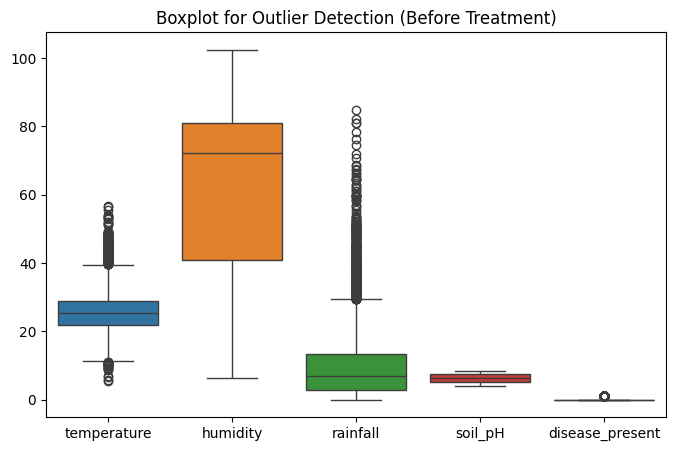

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection (Before Treatment)")
plt.savefig(os.path.join(IMAGES_DIR, "boxplot_before_outlier_treatment.png"), dpi=150, bbox_inches="tight")
plt.show()

In [46]:
# Anomaly check: humidity is a percentage and cannot physically exceed 100
anomalies = df[df['humidity'] > 100]
print("Rows with humidity > 100% (physically impossible):", len(anomalies))
anomalies

Rows with humidity > 100% (physically impossible): 1


,temperature,humidity,rainfall,soil_pH,disease_present
5843,14.380262,102.395421,3.852811,5.171163,0


In [47]:
# Fix the physically impossible value by capping at 100
df.loc[df['humidity'] > 100, 'humidity'] = 100
print("Humidity values > 100 after fix:", (df['humidity'] > 100).sum())

Humidity values > 100 after fix: 0


In [48]:
# IQR-based outlier capping for rainfall (right-skewed with long tail)
def cap_outliers_iqr(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper), lower, upper

for col in ['temperature', 'humidity', 'rainfall', 'soil_pH']:
    before_outliers = ((df[col] < df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25))) |
                        (df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25)))).sum()
    df[col], low, high = cap_outliers_iqr(df[col])
    print(f"{col}: capped to [{low:.2f}, {high:.2f}], {before_outliers} outlier rows affected")

temperature: capped to [11.16, 39.57], 245 outlier rows affected
humidity: capped to [-19.62, 141.42], 0 outlier rows affected
rainfall: capped to [-13.13, 29.39], 496 outlier rows affected
soil_pH: capped to [1.73, 10.78], 0 outlier rows affected


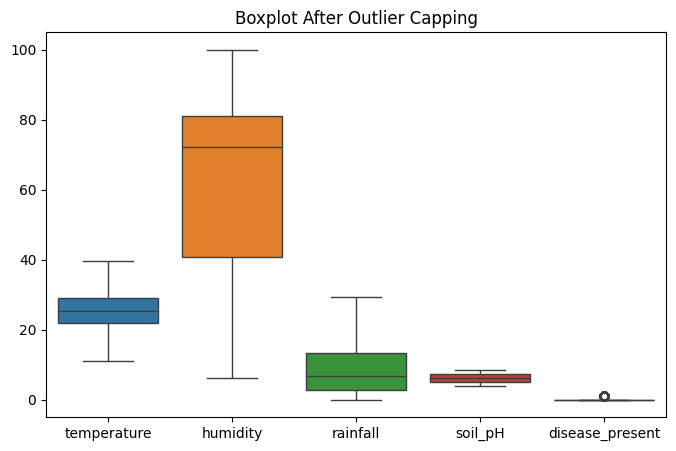

In [54]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.title("Boxplot After Outlier Capping")
plt.savefig(os.path.join(IMAGES_DIR, "boxplot_after_outlier_treatment.png"), dpi=150, bbox_inches="tight")
plt.show()

### Exploratory Data Analysis

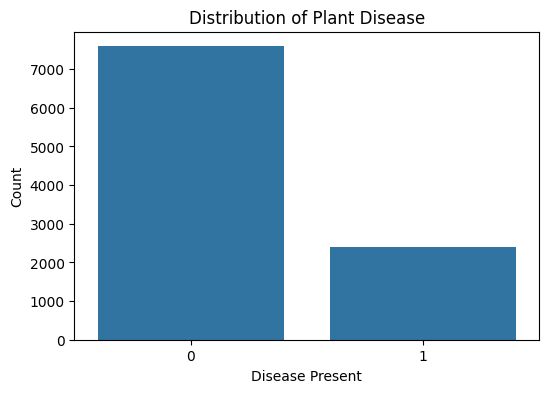

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x="disease_present", data=df)
plt.title("Distribution of Plant Disease")
plt.xlabel("Disease Present")
plt.ylabel("Count")
plt.savefig(os.path.join(IMAGES_DIR, "disease_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

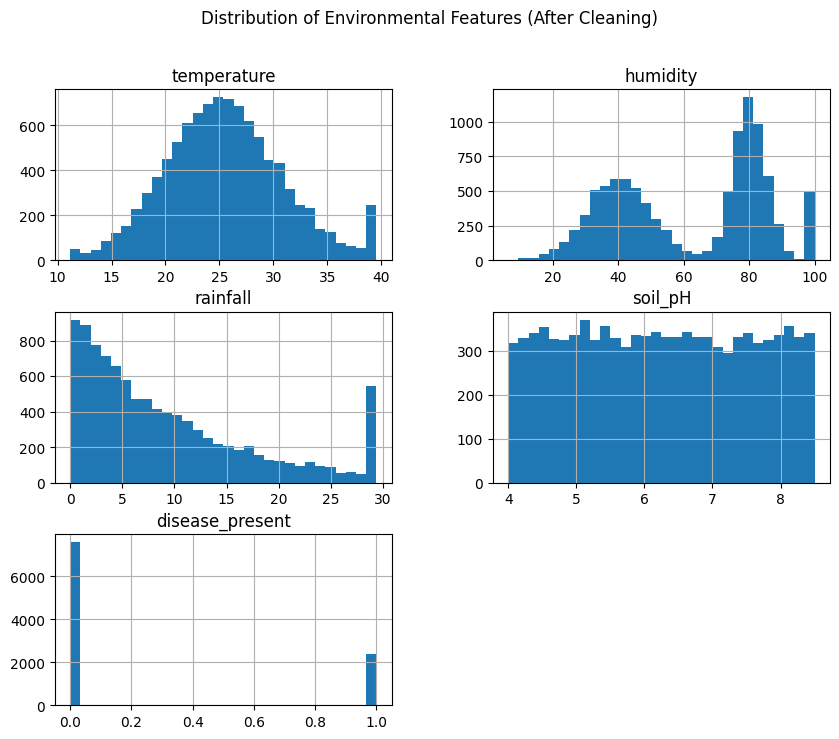

In [56]:
df.hist(figsize=(10,8), bins=30)
plt.suptitle("Distribution of Environmental Features (After Cleaning)")
plt.savefig(os.path.join(IMAGES_DIR, "feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

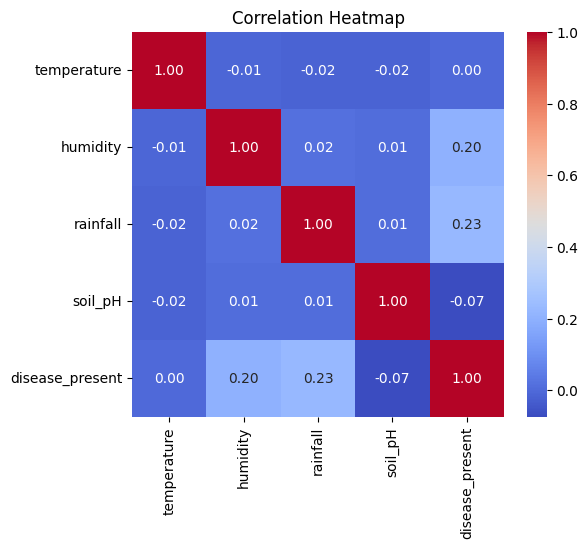

In [57]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig(os.path.join(IMAGES_DIR, "correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

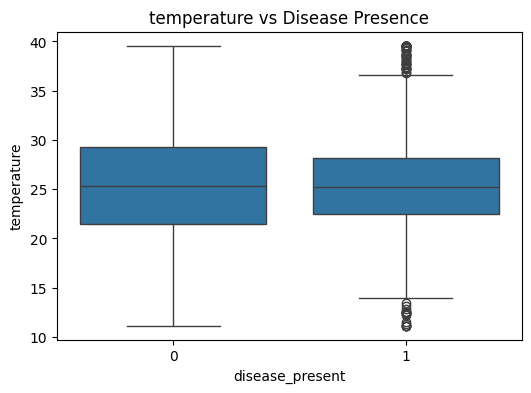

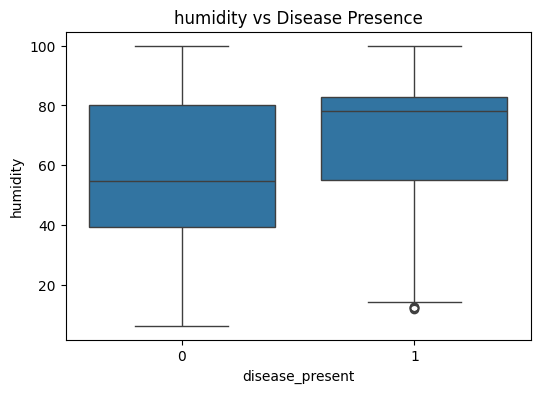

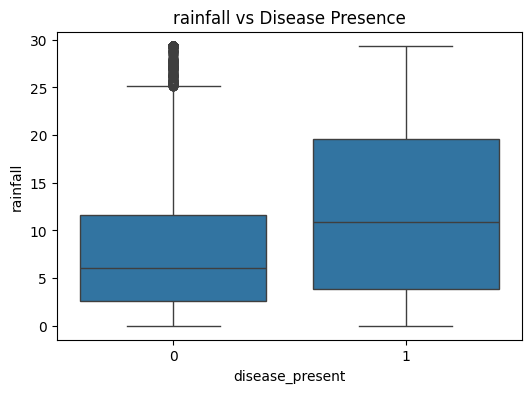

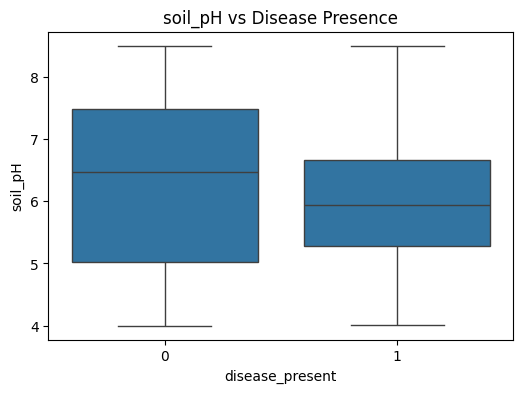

In [58]:
features = ["temperature", "humidity", "rainfall", "soil_pH"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="disease_present", y=feature, data=df)
    plt.title(f"{feature} vs Disease Presence")
    plt.savefig(os.path.join(IMAGES_DIR, f"{feature}_vs_disease.png"), dpi=150, bbox_inches="tight")
    plt.show()

### Feature Engineering
Only 4 raw environmental variables are available, so dimensionality reduction (e.g. PCA) isn't needed here — the goal instead is to create derived features that might expose non-linear/combined effects that Logistic Regression can't capture on its own:

- `temp_humidity_index`: interaction between temperature and humidity (many plant diseases — e.g. fungal blights — are driven by the *combination* of warm + humid conditions, not either alone)
- `rainfall_level`: rainfall bucketed into Low/Medium/High categories (captures threshold effects, e.g. disease risk jumping past a rainfall threshold rather than rising smoothly)
- `soil_pH_deviation`: absolute distance of soil pH from neutral (7.0) — many crops are more disease-prone at extreme pH in either direction, which a plain pH value alone doesn't express

In [59]:
df['temp_humidity_index'] = df['temperature'] * df['humidity'] / 100
df['rainfall_level'] = pd.cut(df['rainfall'], bins=[-0.01, 5, 15, df['rainfall'].max()],
                                labels=['Low', 'Medium', 'High'])
df['soil_pH_deviation'] = (df['soil_pH'] - 7.0).abs()

df[['temperature','humidity','temp_humidity_index','rainfall','rainfall_level','soil_pH','soil_pH_deviation']].head()

,temperature,humidity,temp_humidity_index,rainfall,rainfall_level,soil_pH,soil_pH_deviation
0,27.483571,33.215053,9.128683,0.572758,Low,4.975875,2.024125
1,24.308678,36.945005,8.980843,29.387943,High,8.165266,1.165266
2,28.238443,34.026189,9.608466,16.095303,High,6.316734,0.683266
3,32.615149,41.104180,13.406190,20.311015,High,6.164949,0.835051
4,23.829233,51.971785,12.384478,11.851323,Medium,8.482468,1.482468


In [60]:
# One-hot encode the new categorical feature
df_encoded = pd.get_dummies(df, columns=['rainfall_level'], drop_first=True)
df_encoded.head()

,temperature,humidity,rainfall,soil_pH,disease_present,temp_humidity_index,soil_pH_deviation,rainfall_level_Medium,rainfall_level_High
0,27.483571,33.215053,0.572758,4.975875,1,9.128683,2.024125,False,False
1,24.308678,36.945005,29.387943,8.165266,0,8.980843,1.165266,False,True
2,28.238443,34.026189,16.095303,6.316734,1,9.608466,0.683266,False,True
3,32.615149,41.104180,20.311015,6.164949,0,13.406190,0.835051,False,True
4,23.829233,51.971785,11.851323,8.482468,0,12.384478,1.482468,True,False


### Feature Importance (computed correctly — on training data only, after the split below)

In [61]:
feature_cols = ['temperature', 'humidity', 'rainfall', 'soil_pH',
                'temp_humidity_index', 'soil_pH_deviation'] + \
               [c for c in df_encoded.columns if c.startswith('rainfall_level_')]

X = df_encoded[feature_cols]
y = df_encoded['disease_present']

print("Features:", list(X.columns))
print(X.head())

Features: ['temperature', 'humidity', 'rainfall', 'soil_pH', 'temp_humidity_index', 'soil_pH_deviation', 'rainfall_level_Medium', 'rainfall_level_High']
   temperature   humidity   rainfall   soil_pH  temp_humidity_index  \
0    27.483571  33.215053   0.572758  4.975875             9.128683   
1    24.308678  36.945005  29.387943  8.165266             8.980843   
2    28.238443  34.026189  16.095303  6.316734             9.608466   
3    32.615149  41.104180  20.311015  6.164949            13.406190   
4    23.829233  51.971785  11.851323  8.482468            12.384478   

   soil_pH_deviation  rainfall_level_Medium  rainfall_level_High  
0           2.024125                  False                False  
1           1.165266                  False                 True  
2           0.683266                  False                 True  
3           0.835051                  False                 True  
4           1.482468                   True                False  


### Train/Test Split and Scaling
Fixing the earlier methodology issue: the scaler is now fit **only on the training set**, then applied to the test set. Fitting it on the full dataset before splitting leaks test-set statistics into training. Also adding `stratify=y` since the target is imbalanced (~76/24), to keep the same class ratio in both train and test sets.

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Features:", X_train_scaled.shape)
print("Testing Features :", X_test_scaled.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (8000, 8)
Testing Features : (2000, 8)
Training Labels  : (8000,)
Testing Labels   : (2000,)


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_importance_model = RandomForestClassifier(random_state=42)
rf_importance_model.fit(X_train_scaled, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importance_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                 Feature  Importance
3                soil_pH    0.197023
4    temp_humidity_index    0.161514
5      soil_pH_deviation    0.158949
0            temperature    0.152458
1               humidity    0.150226
2               rainfall    0.144852
7    rainfall_level_High    0.028889
6  rainfall_level_Medium    0.006088


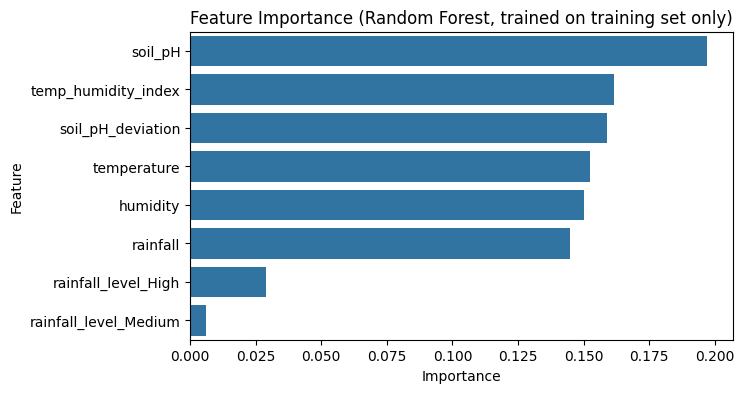

In [64]:
plt.figure(figsize=(7,4))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance (Random Forest, trained on training set only)")
plt.savefig(os.path.join(IMAGES_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

### Model Training & Evaluation

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression")
print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

Logistic Regression
Accuracy : 0.7805
Precision: 0.6080402010050251
Recall   : 0.25103734439834025
F1 Score : 0.355359765051395


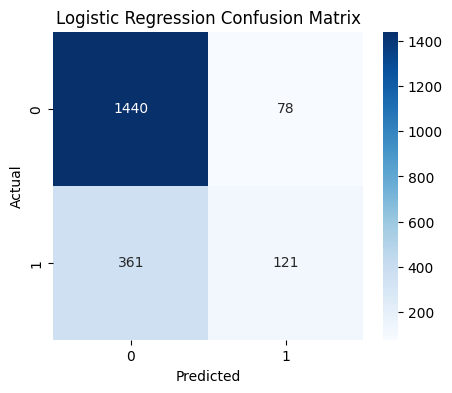

In [66]:
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(os.path.join(IMAGES_DIR, "confusion_matrix_logistic_regression.png"), dpi=150, bbox_inches="tight")
plt.show()

In [67]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
Accuracy : 0.864
Precision: 0.7792553191489362
Recall   : 0.6078838174273858
F1 Score : 0.682983682983683


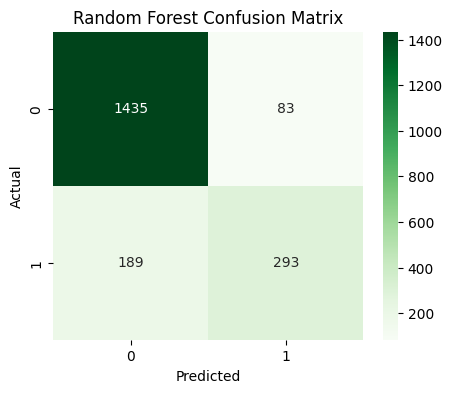

In [68]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(os.path.join(IMAGES_DIR, "confusion_matrix_random_forest.png"), dpi=150, bbox_inches="tight")
plt.show()

### Model Comparison

In [69]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1 Score": [log_f1, rf_f1]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7805,0.608040,0.251037,0.355360
1,Random Forest,0.8640,0.779255,0.607884,0.682984


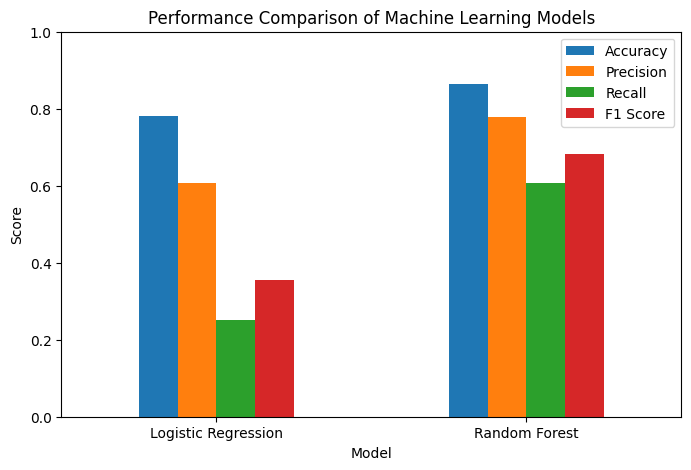

In [70]:
comparison.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Performance Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.savefig(os.path.join(IMAGES_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [10]:
best_model = comparison.sort_values(by="Accuracy", ascending=False)
best_model

NameError: name 'comparison' is not defined

**Random Forest is the better model** — higher accuracy AND substantially better recall than Logistic Regression. This makes sense: Logistic Regression assumes a linear decision boundary, but the relationship between environmental conditions and disease onset is likely threshold-driven (e.g. disease risk rises sharply once rainfall or humidity crosses a certain point, rather than increasing steadily) — a pattern Random Forest's tree splits can capture but a linear model structurally cannot.